# Naive Bayes

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

In [2]:
X,y = make_blobs(n_samples=[20,30], centers=[[+1,+0.5],[-1,-.05]])
X,y

(array([[ 1.35532762,  0.46396652],
        [-0.32856783,  0.6444695 ],
        [-0.53772749, -0.43181575],
        [-0.12151574, -0.21970695],
        [-0.205856  , -0.2364684 ],
        [ 0.58901691,  0.15452441],
        [-0.74070978,  1.49155934],
        [ 1.14548756, -0.34134528],
        [-1.58812121, -0.27272681],
        [-1.9758959 ,  0.58981595],
        [ 1.02292903,  1.12184007],
        [ 1.79144683, -0.3693625 ],
        [-1.81912603,  0.10173725],
        [-1.50317427, -1.23685649],
        [ 0.97903819,  0.13333606],
        [-0.17891864,  1.08805286],
        [ 1.30946848,  0.41873934],
        [-0.06089635,  0.49303465],
        [ 2.01435304, -0.16211662],
        [ 0.83541   ,  1.7370418 ],
        [-0.89726771,  0.89414503],
        [-1.73875165, -0.65880202],
        [-1.33663776,  0.99855807],
        [ 2.4720629 ,  0.82072106],
        [ 0.63448064,  2.01525724],
        [ 1.10077638,  1.66800158],
        [-1.66030932,  0.76759364],
        [-0.07317524,  1.521

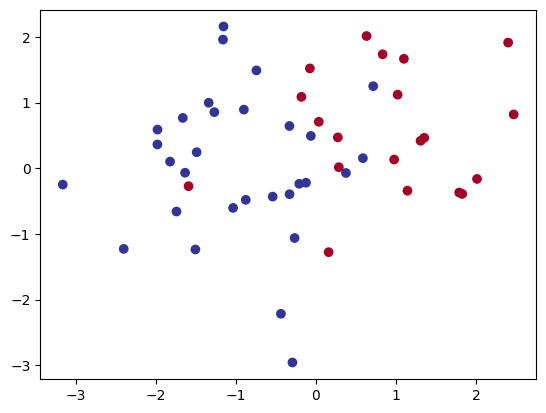

In [3]:
plt.scatter(X[:,0],X[:,1], c=y ,cmap='RdYlBu')
plt.show()

In [ ]:
# this isn't regression so we don't need to add intercept now

In [4]:
P0 = np.sum(y==0)/len(y) #prior probability of class 0
P1 = np.sum(y==1)/len(y) #prior probability of class 1

In [6]:
P0, P1

(np.float64(0.4), np.float64(0.6))

In [18]:
mu0_0 = np.mean(X[y==0,0])  # Mean of feature 0 in class 0
var0_0 = np.var(X[y==0,0])  # varieance of feature 0 in class 0

mu0_1 = np.mean(X[y==1,0])  # Mean of feature 0 in class 1
var0_1 = np.var(X[y==1,0])  # varieance of feature 0 in class 1

mu1_0 = np.mean(X[y==0,1])  # Mean of feature 1 in class 0
var1_0 = np.var(X[y==0,1])  # varieance of feature 1 in class 0

mu1_1 = np.mean(X[y==1,1])  # Mean of feature 1 in class 1
var1_1 = np.var(X[y==1,1])  # varieance of feature 1 in class 1

In [23]:
def guassian(x,mu,var):
    return 1.0 / np.sqrt(2.0*np.pi*var) * np.exp(-0.5 * (x-mu)**2 /var)

In [24]:
# for class 0
P0_0 = guassian(X[:,0],mu0_0,var0_0)  # probability density of feature 0 in class 0
P1_0 = guassian(X[:,1],mu1_0,var1_0)  # probability density of feature 1 in class 0

P0_X = P0_0 * P1_0 * P0 # Likelihood of class 0, given data X


# for class 1
P0_1 = guassian(X[:,0],mu0_1,var0_1)  # probability density of feature 0 in class 1
P1_1 = guassian(X[:,1],mu1_1,var1_1)  # probability density of feature 1 in class 1

P1_X = P1 * P0_1 * P1_1 # Likelihood of class 1, given data X

In [33]:
likelihoods = np.array([P0_X,P1_X]).T
likelihoods

array([[6.56501022e-02, 2.99349388e-03],
       [3.31641077e-02, 6.53974454e-02],
       [1.32171073e-02, 8.06493564e-02],
       [2.89937888e-02, 6.15164951e-02],
       [2.59058197e-02, 6.67644024e-02],
       [6.35598198e-02, 2.12763556e-02],
       [1.02805304e-02, 3.92153328e-02],
       [4.27325223e-02, 5.53037130e-03],
       [1.73891608e-03, 7.35246716e-02],
       [8.84544410e-04, 4.44807611e-02],
       [6.04368653e-02, 4.89865385e-03],
       [2.76690776e-02, 7.40396924e-04],
       [1.23865016e-03, 6.11056074e-02],
       [4.37331817e-04, 4.17789623e-02],
       [6.57375116e-02, 8.95397204e-03],
       [3.36910644e-02, 4.19511815e-02],
       [6.66298646e-02, 3.47689964e-03],
       [4.54009740e-02, 5.39506881e-02],
       [2.69515679e-02, 3.44963231e-04],
       [3.11347269e-02, 3.75406233e-03],
       [1.23681827e-02, 7.19566055e-02],
       [6.95691623e-04, 5.47362329e-02],
       [4.54464815e-03, 6.07086743e-02],
       [1.85053921e-02, 4.14922809e-05],
       [1.899939

In [37]:
probabilities = likelihoods/ np.sum(likelihoods, axis=1 , keepdims=True)
probabilities

array([[0.95639078, 0.04360922],
       [0.33648118, 0.66351882],
       [0.14080756, 0.85919244],
       [0.32033696, 0.67966304],
       [0.27954848, 0.72045152],
       [0.74920657, 0.25079343],
       [0.20770484, 0.79229516],
       [0.88541153, 0.11458847],
       [0.02310435, 0.97689565],
       [0.01949826, 0.98050174],
       [0.92502311, 0.07497689],
       [0.97393838, 0.02606162],
       [0.01986791, 0.98013209],
       [0.01035931, 0.98964069],
       [0.88012058, 0.11987942],
       [0.44540011, 0.55459989],
       [0.95040565, 0.04959435],
       [0.45697247, 0.54302753],
       [0.98736238, 0.01263762],
       [0.89239918, 0.10760082],
       [0.14667315, 0.85332685],
       [0.01255038, 0.98744962],
       [0.06964623, 0.93035377],
       [0.99776284, 0.00223716],
       [0.83417204, 0.16582796],
       [0.93984971, 0.06015029],
       [0.03650498, 0.96349502],
       [0.51626144, 0.48373856],
       [0.97588833, 0.02411167],
       [0.04900558, 0.95099442],
       [0.

In [ ]:
# in above we see for example first row the instance belong to class o because class 0 has bigger number

In [ ]:
# now I want to have y_hat and yhat for first instance should return 0 means this instance belong to class 0

In [30]:
y_hat = (likelihoods[:,0]<likelihoods[:,1]).astype(int)
y_hat

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0])

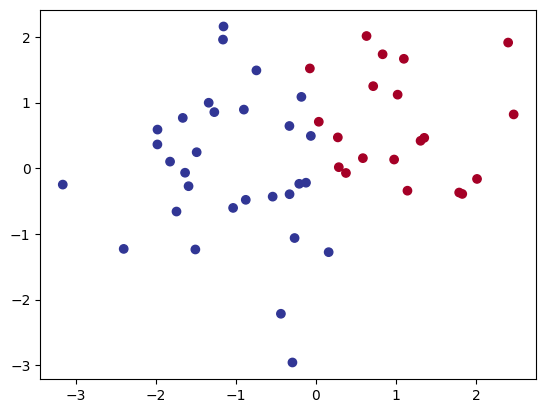

In [31]:
plt.scatter(X[:,0],X[:,1], c=y_hat ,cmap='RdYlBu')
plt.show()

In [ ]:
# this works because we had two classes but what if we have more than 2 classes for example , we want to find out which class has the
# biggest value and we say the instance belong to that class

In [34]:
y_hat = np.argmax(likelihoods, axis=1)
y_hat

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0])